# Breast Cancer Classification Prediction Tool

### Dunder Regional Cancer Center (DRCC) - C964 Computer Science Capstone

**Purpose:** This notebook uses a Logistic Regression model trained on the Breast Cancer Wisconsin (Diagnostic) Dataset from the UCI Machine Learning Repository to predict whether a tumor is malignant or benign. The predictions are based on cell nucleus measurements taken directly from fine needle aspirate (FNA) biopsy images.




---
### How to Use This Notebook:
1. Click **Runtime** in the top menu bar
2. Click **Run all**
3. Wait for all cells to finish running (this should take around 30-60 seconds)
4. Scroll to the bottom to find the Interactive Prediction Tool
5. Adjust the sliders to enter tumor measurements
6. Click **Predict Diagnosis** to see the result

In [19]:
!pip install ipywidgets
from google.colab import output
output.enable_custom_widget_manager()

# Import data manipulation libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import machine learning tools
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
  accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Import interactive widget tools
import ipywidgets as widgets
from IPython.display import display, HTML

print('All libraries have been imported successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.6 MB/s eta 0:00:00
All libraries have been imported successfully.


In [20]:
# This is the raw dataset URL hosted on my github repo
GITHUB_URL = 'https://raw.githubusercontent.com/sondrak-beep-boop/c964-capstone/main/data.csv'

# Loads dataset into a pandas DataFrame
df = pd.read_csv(GITHUB_URL)

# Drops irrelevant columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# Encodes target variables: M (Malignant) = 1, B (Benign) = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(f'Dataset loaded: {df.shape[0]} patients, {df.shape[1]} columns')
print(f"Malignant cases: {df['diagnosis'].sum()} | Benign cases: {(df['diagnosis'] == 0).sum()}")
df.head()

Dataset loaded: 569 patients, 31 columns
Malignant cases: 212 | Benign cases: 357


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


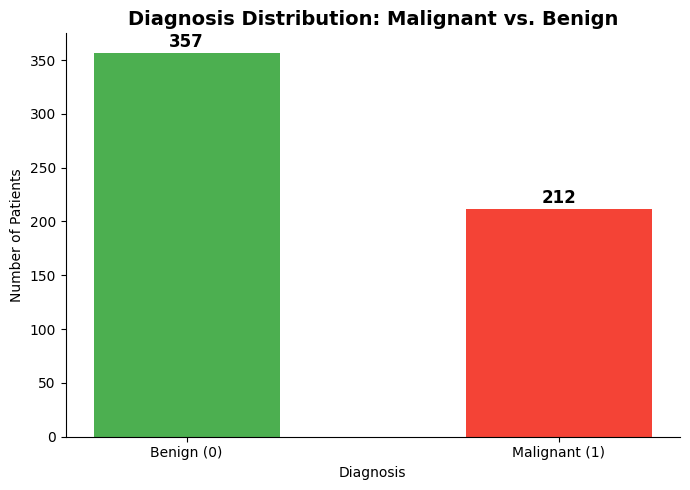

Visualization 1 is complete.


In [21]:

# Visualization 1: Bar chart that shows class distribution of diagnoses
fig, ax = plt.subplots(figsize=(7, 5))

counts = df['diagnosis'].value_counts()
bars = ax.bar(
    ['Benign (0)', 'Malignant (1)'],
    [counts[0], counts[1]],
    color=['#4CAF50', '#F44336'],
    width=0.5
)

# Adds count labels on top of each bar
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('Diagnosis Distribution: Malignant vs. Benign', fontsize=14, fontweight='bold')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Number of Patients')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('visualization_img_1_diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 1 is complete.')

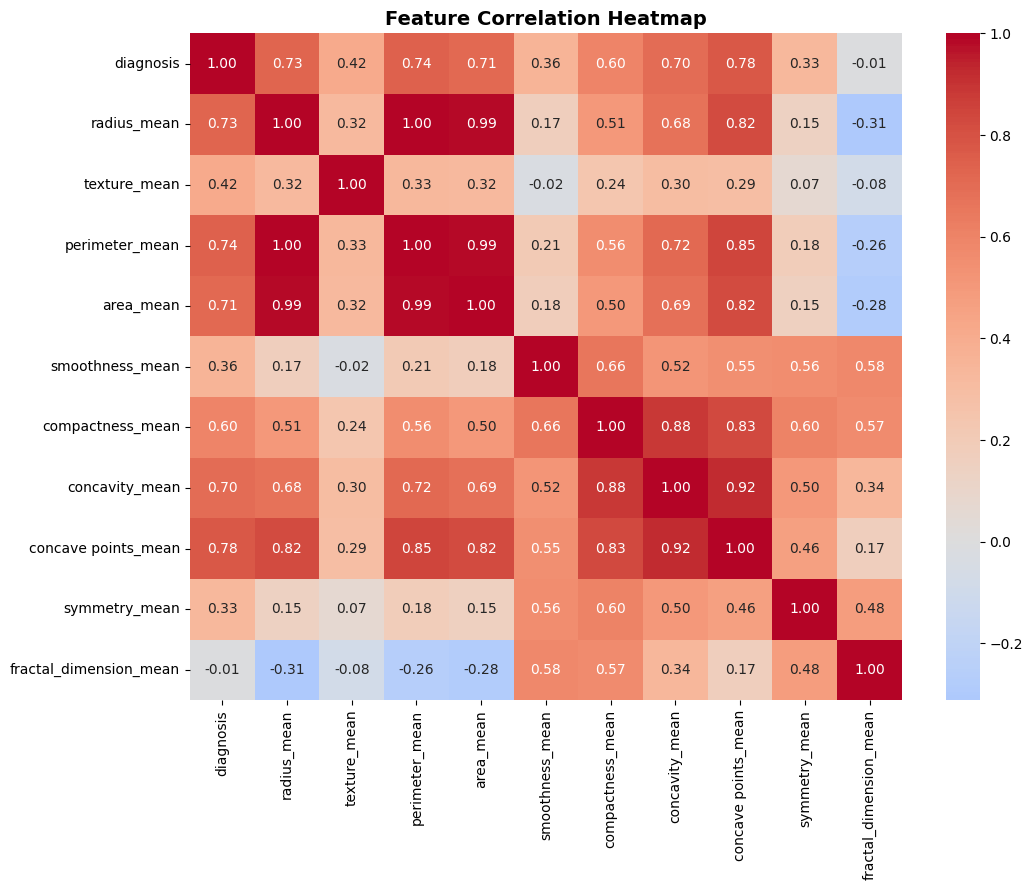

Visualization 2 is complete.


In [22]:
# Visualization 2: Correlation heatmap of the 10 core mean tumor features
mean_features = [
    'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
    'area_mean', 'smoothness_mean', 'compactness_mean',
    'concavity_mean', 'concave points_mean', 'symmetry_mean',
    'fractal_dimension_mean'
]

# Calculates correlation matrix
corr = df[mean_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualization_img_2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 2 is complete.')

In [23]:
# This separates features from the target variable
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# This splits data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# This scales features, which is required for Logistic Regression to perform well
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# This trains the Logistic Regression model
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train_scaled, y_train)

# This evaluates model performance on the test set
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Training Is Complete!')
print(f'Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

Model Training Is Complete!
Test Accuracy: 0.9649 (96.49%)

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



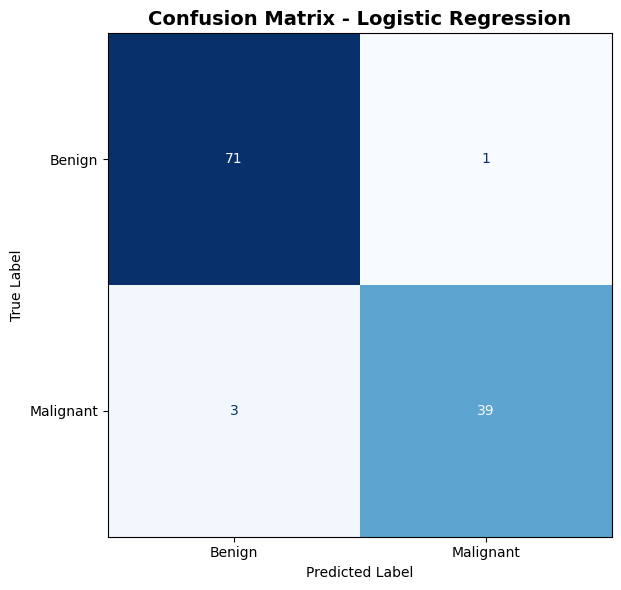

Visualization 3 is complete.


In [24]:
# Visualization 3: Confusion matrix showing prediction results on the test set
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('visualization_img_3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 is complete.')

In [25]:
# This defines slider ranges based on dataset feature ranges
slider_configs = [
    ('Radius Mean',             6.0,  28.0,  14.0,  0.1),
    ('Texture Mean',           10.0,  40.0,  19.0,  0.1),
    ('Perimeter Mean',         43.0, 190.0,  92.0,  0.5),
    ('Area Mean',             140.0,2510.0, 655.0,  5.0),
    ('Smoothness Mean',         0.05,  0.16,  0.096, 0.001),
    ('Compactness Mean',        0.02,  0.35,  0.104, 0.001),
    ('Concavity Mean',          0.0,   0.43,  0.089, 0.001),
    ('Concave Points Mean',     0.0,   0.20,  0.049, 0.001),
    ('Symmetry Mean',           0.10,  0.30,  0.181, 0.001),
    ('Fractal Dimension Mean',  0.05,  0.10,  0.063, 0.001),
]

# This maps readable labels to the dataset column names
column_map = {
    'Radius Mean':            'radius_mean',
    'Texture Mean':           'texture_mean',
    'Perimeter Mean':         'perimeter_mean',
    'Area Mean':              'area_mean',
    'Smoothness Mean':        'smoothness_mean',
    'Compactness Mean':       'compactness_mean',
    'Concavity Mean':         'concavity_mean',
    'Concave Points Mean':    'concave points_mean',
    'Symmetry Mean':          'symmetry_mean',
    'Fractal Dimension Mean': 'fractal_dimension_mean',
}

In [26]:
# This builds FloatSlider widgets for each feature
sliders = {}
for label, mn, mx, default, step in slider_configs:
    sliders[label] = widgets.FloatSlider(
        value=default, min=mn, max=mx, step=step,
        description=label + ':',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='550px')
    )

# This defines the prediction button and the output area
predict_button = widgets.Button(
    description='Predict Diagnosis',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='40px')
)

output_area = widgets.Output()

In [27]:
# This triggers the prediction function when the button is clicked
def on_predict_clicked(b):
    output_area.clear_output()

    # Starts with the median values for all 30 features
    sample = df.drop(columns=['diagnosis']).median().to_dict()

    # Override with user slider values
    for label, slider in sliders.items():
        col = column_map[label]
        sample[col] = slider.value

    # Scales input and generates prediction
    sample_df = pd.DataFrame([sample])[X.columns]
    sample_scaled = scaler.transform(sample_df)
    prediction = model.predict(sample_scaled)[0]
    probability = model.predict_proba(sample_scaled)[0]
    benign_pct = probability[0] * 100
    malignant_pct = probability[1] * 100

    if prediction == 1:
        result_html = f"""
        <div style="background:#FFEBEE; border-left:6px solid #F44336;
                    padding:16px 20px; border-radius:6px; margin-top:12px;">
            <h3 style="color:#C62828; margin:0 0 8px 0;">⚠ Prediction: MALIGNANT</h3>
            <p>Malignant confidence: <strong>{malignant_pct:.1f}%</strong></p>
            <p>Benign confidence: <strong>{benign_pct:.1f}%</strong></p>
            <p style="font-size:12px; color:#555;">Clinical follow-up is strongly recommended.</p>
        </div>
        """
    else:
        result_html = f"""
        <div style="background:#E8F5E9; border-left:6px solid #4CAF50;
                    padding:16px 20px; border-radius:6px; margin-top:12px;">
            <h3 style="color:#2E7D32; margin:0 0 8px 0;">✓ Prediction: BENIGN</h3>
            <p>Benign confidence: <strong>{benign_pct:.1f}%</strong></p>
            <p>Malignant confidence: <strong>{malignant_pct:.1f}%</strong></p>
            <p style="font-size:12px; color:#555;">Routine monitoring is still recommended.</p>
        </div>
        """

    with output_area:
        display(HTML(result_html))

predict_button.on_click(on_predict_clicked)

# This displays the interactive prediction tool
display(HTML('<h3>🔬 Enter Tumor Measurements</h3>'))
display(HTML('<p>Adjust the sliders and click Predict Diagnosis to get a prediction.</p>'))
for slider in sliders.values():
    display(slider)
display(widgets.HBox([predict_button]))
display(output_area)

FloatSlider(value=14.0, description='Radius Mean:', layout=Layout(width='550px'), max=28.0, min=6.0, style=Sli…

FloatSlider(value=19.0, description='Texture Mean:', layout=Layout(width='550px'), max=40.0, min=10.0, style=S…

FloatSlider(value=92.0, description='Perimeter Mean:', layout=Layout(width='550px'), max=190.0, min=43.0, step…

FloatSlider(value=655.0, description='Area Mean:', layout=Layout(width='550px'), max=2510.0, min=140.0, step=5…

FloatSlider(value=0.096, description='Smoothness Mean:', layout=Layout(width='550px'), max=0.16, min=0.05, ste…

...

FloatSlider(value=0.089, description='Concavity Mean:', layout=Layout(width='550px'), max=0.43, step=0.001, st…

FloatSlider(value=0.049, description='Concave Points Mean:', layout=Layout(width='550px'), max=0.2, step=0.001…

FloatSlider(value=0.181, description='Symmetry Mean:', layout=Layout(width='550px'), max=0.3, min=0.1, step=0.…

FloatSlider(value=0.063, description='Fractal Dimension Mean:', layout=Layout(width='550px'), max=0.1, min=0.0…

Output()